# Ollama Open-Model Comparison (Baseline, Seeds 1-3)

This notebook compares local Ollama planners (`qwen3:4b`, `gemma3:4b`, `llama3.1:8b`) using benchmark helpers in `tcrb`.

- Set `RUN_BENCHMARKS = True` to run fresh simulations.
- Keep it `False` to analyze cached results in `analysis/ollama_open_models_baseline_s10.json`.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt

from tcrb.config import load_benchmark_config, load_workload
from tcrb.experiments import run_multi_seed
from tcrb.planner import load_tool_planner


In [2]:
ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

RUN_BENCHMARKS = False
SEEDS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
CONFIG_PATH = ROOT / "configs/baseline.json"
WORKLOAD_PATH = ROOT / "workloads/sample_tasks.json"
ANALYSIS_PATH = ROOT / "analysis/ollama_open_models_baseline_s10.json"

MODEL_PLANNERS = {
    "qwen3:4b": ROOT / "configs/planners/ollama_qwen3_4b.json",
    "gemma3:4b": ROOT / "configs/planners/ollama_gemma3_4b.json",
    "llama3.1:8b": ROOT / "configs/planners/ollama_llama3_1_8b.json",
}

ROOT


PosixPath('/Users/aaliyan/aaliyan/tool-calling-reliability-benchmark')

In [3]:
def run_model(planner_path: Path, seeds: list[int]) -> dict:
    workload = load_workload(str(WORKLOAD_PATH))
    config = load_benchmark_config(str(CONFIG_PATH))
    planner = load_tool_planner(str(planner_path))
    return run_multi_seed(workload=workload, config=config, seeds=seeds, planner=planner)


def build_comparison_payload(model_payloads: dict[str, dict], seeds: list[int]) -> dict:
    rows: list[dict] = []
    run_paths: dict[str, str] = {}

    for model, payload in model_payloads.items():
        run_paths[model] = "generated-in-notebook"
        for entry in payload["aggregate_policy_metrics"]:
            metrics = entry["metrics"]
            rows.append(
                {
                    "model": model,
                    "policy": entry["policy"],
                    "task_success_rate": metrics["task_success_rate"]["mean"],
                    "invalid_tool_call_rate": metrics["invalid_tool_call_rate"]["mean"],
                    "mean_latency_ms": metrics["mean_latency_ms"]["mean"],
                    "p95_latency_ms": metrics["p95_latency_ms"]["mean"],
                    "retries_per_successful_task": metrics["retries_per_successful_task"]["mean"],
                    "estimated_cost_per_successful_task_usd": metrics["estimated_cost_per_successful_task_usd"]["mean"],
                }
            )

    return {
        "analysis_label": "ollama_open_models_baseline_s10",
        "config_path": str(CONFIG_PATH.relative_to(ROOT)),
        "workload_path": str(WORKLOAD_PATH.relative_to(ROOT)),
        "seeds": seeds,
        "run_paths": run_paths,
        "aggregate_metrics": rows,
    }


In [4]:
if RUN_BENCHMARKS:
    model_payloads = {}
    for model, planner_path in MODEL_PLANNERS.items():
        print(f"Running benchmark for {model} ...")
        model_payloads[model] = run_model(planner_path, SEEDS)

    comparison = build_comparison_payload(model_payloads, SEEDS)
    ANALYSIS_PATH.parent.mkdir(parents=True, exist_ok=True)
    ANALYSIS_PATH.write_text(json.dumps(comparison, indent=2), encoding="utf-8")
else:
    comparison = json.loads(ANALYSIS_PATH.read_text(encoding="utf-8"))

comparison["analysis_label"], comparison["seeds"]


('ollama_open_models_baseline_s10', [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

In [5]:
rows = comparison["aggregate_metrics"]

for model in MODEL_PLANNERS:
    model_rows = [r for r in rows if r["model"] == model]
    best_success = max(model_rows, key=lambda r: r["task_success_rate"])
    best_cost = min(model_rows, key=lambda r: r["estimated_cost_per_successful_task_usd"])
    best_p95 = min(model_rows, key=lambda r: r["p95_latency_ms"])

    print(model)
    print("  best success:", best_success["policy"], f"({best_success['task_success_rate']:.4f})")
    print("  best p95:", best_p95["policy"], f"({best_p95['p95_latency_ms']:.2f} ms)")
    print("  best cost:", best_cost["policy"], f"(${best_cost['estimated_cost_per_successful_task_usd']:.6f})")
    print()


qwen3:4b
  best success: schema_first_fallback (0.6500)
  best p95: timeout_budget_early_abort (875.10 ms)
  best cost: timeout_budget_early_abort ($0.001114)

gemma3:4b
  best success: schema_first_fallback (0.8333)
  best p95: timeout_budget_early_abort (1035.50 ms)
  best cost: exponential_backoff_jitter ($0.001287)

llama3.1:8b
  best success: schema_first_fallback (0.8000)
  best p95: timeout_budget_early_abort (901.60 ms)
  best cost: timeout_budget_early_abort ($0.001164)



PosixPath('/Users/aaliyan/aaliyan/tool-calling-reliability-benchmark/analysis/ollama_open_models_baseline_s10_frontier.png')

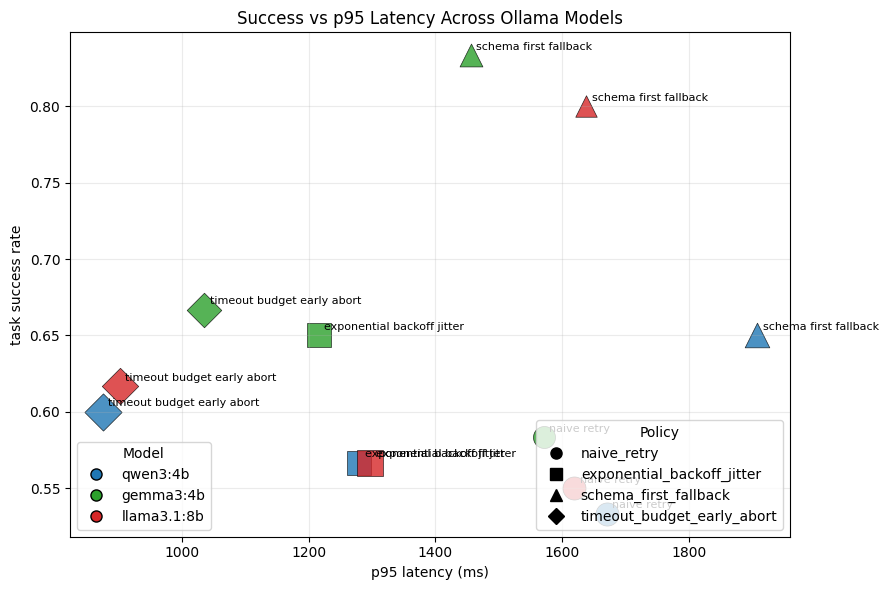

In [6]:
model_colors = {
    "qwen3:4b": "#1f77b4",
    "gemma3:4b": "#2ca02c",
    "llama3.1:8b": "#d62728",
}

policy_markers = {
    "naive_retry": "o",
    "exponential_backoff_jitter": "s",
    "schema_first_fallback": "^",
    "timeout_budget_early_abort": "D",
}

fig, ax = plt.subplots(figsize=(9, 6))

for row in rows:
    model = row["model"]
    policy = row["policy"]
    cost = max(1e-6, row["estimated_cost_per_successful_task_usd"])
    size = 250 * (0.0016 / cost)

    ax.scatter(
        row["p95_latency_ms"],
        row["task_success_rate"],
        s=size,
        c=model_colors[model],
        marker=policy_markers[policy],
        alpha=0.8,
        edgecolor="black",
        linewidth=0.5,
    )

    ax.annotate(
        policy.replace("_", " "),
        (row["p95_latency_ms"], row["task_success_rate"]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=8,
    )

ax.set_title("Success vs p95 Latency Across Ollama Models")
ax.set_xlabel("p95 latency (ms)")
ax.set_ylabel("task success rate")
ax.grid(alpha=0.25)

from matplotlib.lines import Line2D

model_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=color, markeredgecolor="black", markersize=8, label=model)
    for model, color in model_colors.items()
]

policy_handles = [
    Line2D([0], [0], marker=marker, color="black", linestyle="None", markersize=8, label=policy)
    for policy, marker in policy_markers.items()
]

legend1 = ax.legend(handles=model_handles, title="Model", loc="lower left")
ax.add_artist(legend1)
ax.legend(handles=policy_handles, title="Policy", loc="lower right")

out_path = ROOT / "analysis/ollama_open_models_baseline_s10_frontier.png"
fig.tight_layout()
fig.savefig(out_path, dpi=200)
out_path
